In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [2]:
MODEL_PATH = "../models/trained_plant_disease_model.keras"

VALID_DIR = "../dataset/valid"

IMG_SIZE = (128,128)

In [3]:
model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=False,
    label_mode="categorical"
)

Found 17572 files belonging to 38 classes.


In [5]:
import json

with open("../models/class_names.json", "r") as f:
    class_names = json.load(f)
    
print("Classes:", len(class_names))

Classes: 38


In [6]:
model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

loss, acc = model.evaluate(test_ds)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 71s 127ms/step - accuracy: 0.9548 - loss: 0.1311
Loss: 0.1311
Accuracy: 0.9548


In [7]:
predictions = model.predict(test_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

550/550 ━━━━━━━━━━━━━━━━━━━━ 72s 130ms/step


In [8]:
y_true = []

for images, labels in test_ds:

    y_true.extend(
        np.argmax(
            labels.numpy(),
            axis=1
        )
    )

y_true = np.array(y_true)

In [9]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.head()

,precision,recall,f1-score,support
Apple___Apple_scab,0.960474,0.964286,0.962376,504.0
Apple___Black_rot,0.980080,0.989940,0.984985,497.0
Apple___Cedar_apple_rust,0.997658,0.968182,0.982699,440.0
Apple___healthy,0.953578,0.982072,0.967615,502.0
Blueberry___healthy,0.993304,0.980176,0.986696,454.0


In [10]:
report_df.to_csv(
    "../docs/classification_report.csv"
)

In [11]:
cm = confusion_matrix(
    y_true,
    y_pred
)

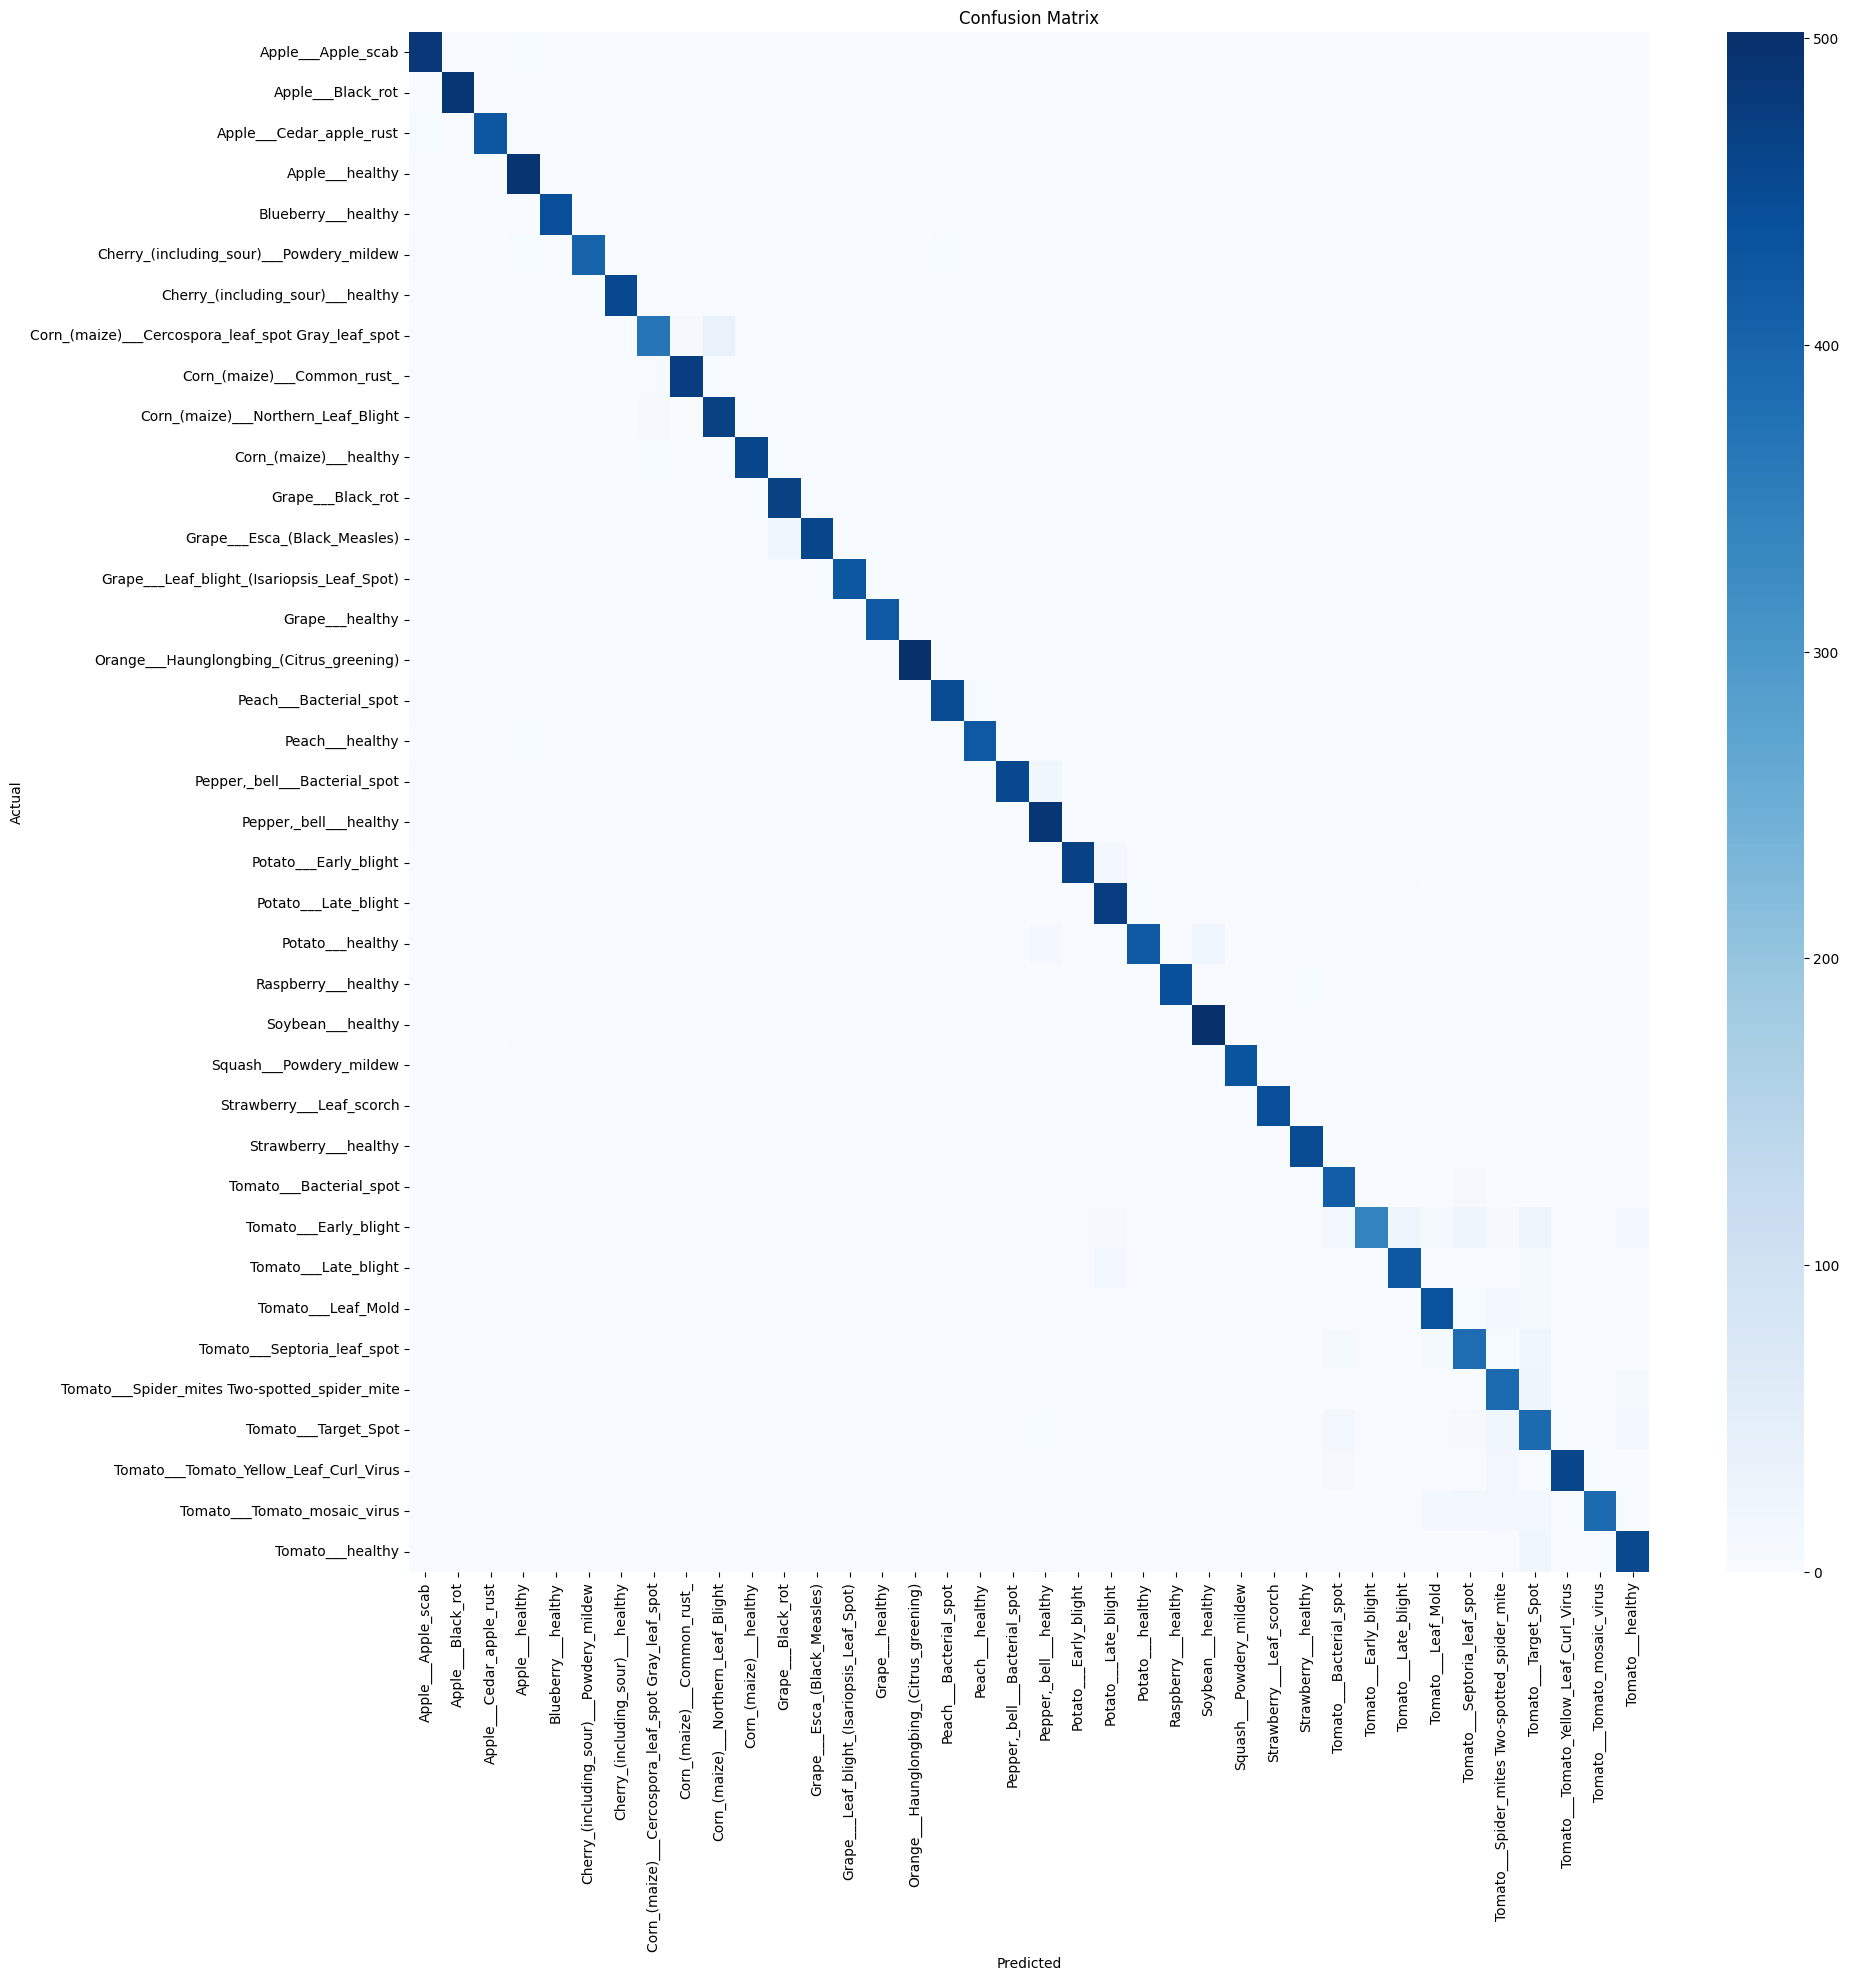

In [12]:
plt.figure(figsize=(20,20))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.savefig(
    "../docs/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
errors = []

for actual, pred in zip(
    y_true,
    y_pred
):
    if actual != pred:

        errors.append(
            (
                class_names[actual],
                class_names[pred]
            )
        )

len(errors)

795

In [14]:
from collections import Counter

error_counter = Counter(errors)

error_counter.most_common(10)

[(('Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
   'Corn_(maize)___Northern_Leaf_Blight'),
  37),
 (('Tomato___Early_blight', 'Tomato___Target_Spot'), 26),
 (('Tomato___Early_blight', 'Tomato___Late_blight'), 25),
 (('Tomato___Early_blight', 'Tomato___Septoria_leaf_spot'), 25),
 (('Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot'),
  24),
 (('Grape___Esca_(Black_Measles)', 'Grape___Black_rot'), 20),
 (('Tomato___Septoria_leaf_spot', 'Tomato___Target_Spot'), 20),
 (('Tomato___healthy', 'Tomato___Target_Spot'), 20),
 (('Potato___healthy', 'Soybean___healthy'), 19),
 (('Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy'), 18)]

In [15]:
images = []
labels = []

for img, label in test_ds:

    images.append(img.numpy()[0])

    labels.append(
        np.argmax(label.numpy())
    )

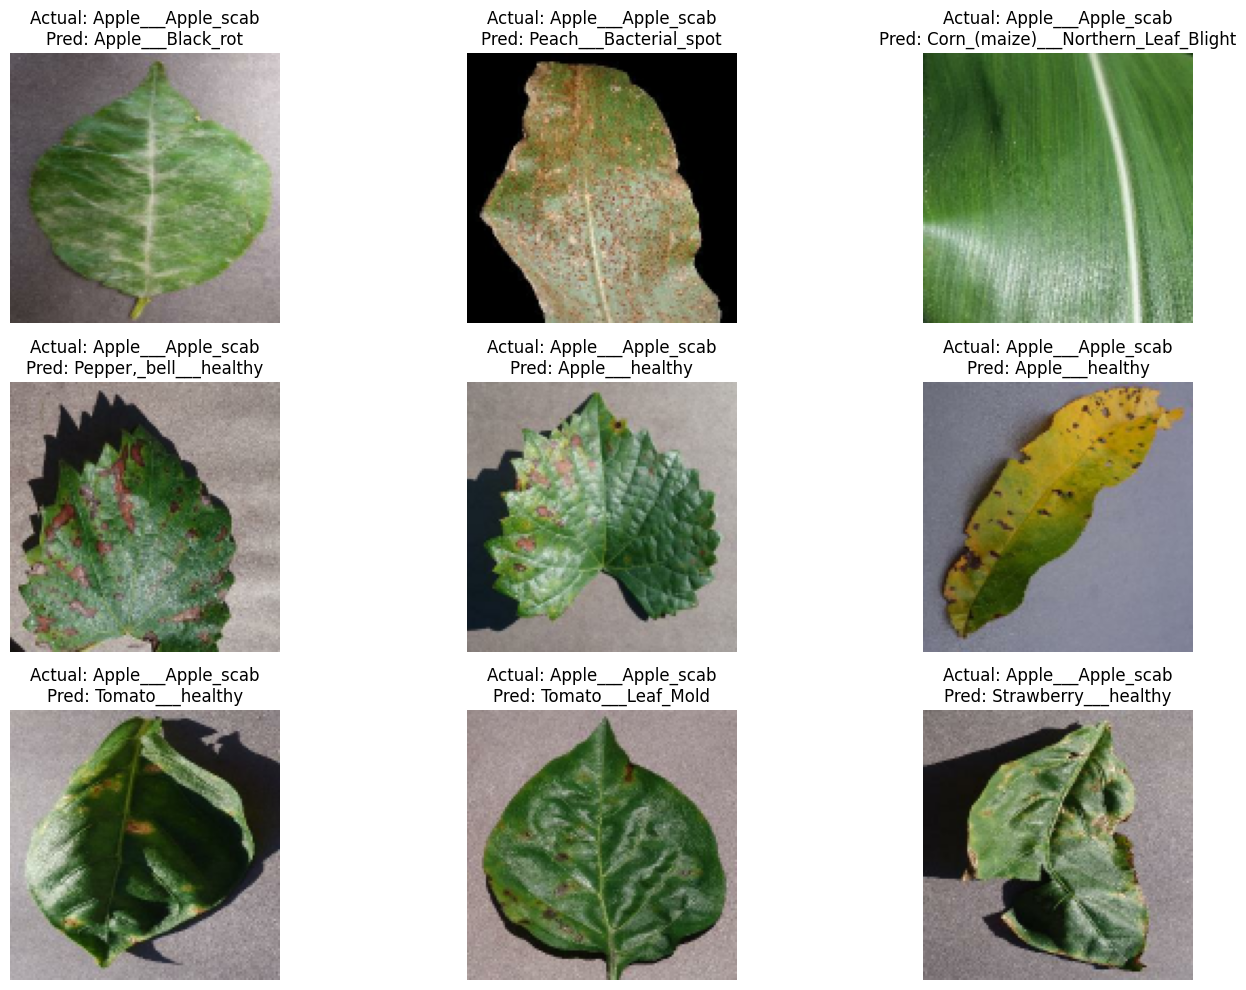

In [16]:
plt.figure(figsize=(15,10))

wrong = 0

for i in range(len(y_true)):

    if y_true[i] != y_pred[i]:

        plt.subplot(3,3,wrong+1)

        plt.imshow(
            images[i].astype("uint8")
        )

        plt.title(
            f"Actual: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}"
        )

        plt.axis("off")

        wrong += 1

        if wrong == 9:
            break

plt.tight_layout()

plt.show()